In [1]:
import pandas as pd
import numpy as np
import polars as pl
import scipy.sparse as sp
import joblib
import os
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,f1_score
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

d:\soc_sentinel\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pl.read_parquet("../data/03_processed/baseline_features_train.parquet").to_pandas()
df = df.dropna(subset='IncidentGrade')
label_map = {
    "FalsePositive" : 0,
    'BenignPositive' : 1,
    'TruePositive' : 2
}
df['target'] = df['IncidentGrade'].map(label_map)


X = df.drop(columns=['IncidentGrade','start_time','end_time','target','OrgId','IncidentId'])
y = df['target']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_test.shape}")
print(f"Target distribution:\n{y_train.value_counts(normalize=True) * 100}")

Training set shape: (358277, 31)
Validation set shape: (89570, 31)
Target distribution:
target
1    48.575823
0    30.119433
2    21.304745
Name: proportion, dtype: float64


In [3]:
rf_baseline = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
print("Training the Random Forest Model ...")
rf_baseline.fit(X_train,y_train)

print("Predicting on validation set ...")
y_pred = rf_baseline.predict(X_test)

print("\n--- Classification Report ---")
target_labels = ['False Positive (0)','Benign Positive (1)','True Positive (2)']
print(classification_report(y_test,y_pred,target_names=target_labels))

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"\nCRITICAL BENCHMARK -> Baseline Macro-F1 Score: {macro_f1:.4f}")

Training the Random Forest Model ...
Predicting on validation set ...

--- Classification Report ---
                     precision    recall  f1-score   support

 False Positive (0)       0.81      0.60      0.69     26978
Benign Positive (1)       0.67      0.87      0.76     43509
  True Positive (2)       0.61      0.39      0.48     19083

           accuracy                           0.69     89570
          macro avg       0.70      0.62      0.64     89570
       weighted avg       0.70      0.69      0.68     89570


CRITICAL BENCHMARK -> Baseline Macro-F1 Score: 0.6430


## Baseline model on engineered features

In [4]:
df = pl.read_parquet("../data/03_processed/engineered_features_train.parquet").to_pandas()
df = df.dropna(subset='IncidentGrade')
df['target'] = df['IncidentGrade'].map(label_map)

X = df.drop(columns=['IncidentGrade','target','OrgId','IncidentId'])
y = df['target']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_test.shape}")
print(f"Target distribution:\n{y_train.value_counts(normalize=True) * 100}")

Training set shape: (358277, 37)
Validation set shape: (89570, 37)
Target distribution:
target
1    48.575823
0    30.119433
2    21.304745
Name: proportion, dtype: float64


In [5]:
rf_baseline = RandomForestClassifier(
    n_estimators = 50,
    max_depth=10,
    random_state=42,
    n_jobs = -1
)

print("Training the Random Forest Model ...")
rf_baseline.fit(X_train,y_train)

print("Predicting on validation set ...")
y_pred = rf_baseline.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test,y_pred,target_names=target_labels))

macro_f1 = f1_score(y_test,y_pred,average='macro')
print(f"\nCRITICAL BENCHMARK -> Baseline Macro-F1 Score: {macro_f1:.4f}")

Training the Random Forest Model ...
Predicting on validation set ...

--- Classification Report ---
                     precision    recall  f1-score   support

 False Positive (0)       0.81      0.61      0.70     26978
Benign Positive (1)       0.67      0.87      0.76     43509
  True Positive (2)       0.62      0.40      0.49     19083

           accuracy                           0.69     89570
          macro avg       0.70      0.63      0.65     89570
       weighted avg       0.70      0.69      0.68     89570


CRITICAL BENCHMARK -> Baseline Macro-F1 Score: 0.6459


In [6]:
importance = pd.Series(rf_baseline.feature_importances_,index=X_train.columns)
print("Top 15 Most Important Features:")
print(importance.sort_values(ascending=False).head(15))

Top 15 Most Important Features:
evidence_per_second             0.089871
total_evidence_count            0.079487
unique_state_count              0.070856
unique_entitytype_count         0.067229
unique_countrycode_count        0.065187
unique_city_count               0.063227
is_multinational                0.061812
unique_sha256_count             0.038290
unique_filename_count           0.035781
unique_url_count                0.034859
ips_per_device                  0.032254
unique_accountobjectid_count    0.029955
unique_accountupn_count         0.029347
unique_applicationname_count    0.027688
unique_applicationid_count      0.027437
dtype: float64


## Version two of improved baseline model

In [7]:
df = pl.read_parquet('../data/03_processed/version_two_engineered_features_train.parquet').to_pandas()
df = df.dropna(subset=['IncidentGrade'])

df['target'] = df['IncidentGrade'].map(label_map)

X = df.drop(columns=['IncidentId','OrgId','IncidentGrade','target','text_AlertTitle','text_FileName'])
y = df['target']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(f"Shape of training data : {X_train.shape}")
print(f"Shape of test data : {X_test.shape}")
print(f"Target distribution in training data : {y_train.value_counts(normalize=True) * 100}")
df

Shape of training data : (358277, 55)
Shape of test data : (89570, 55)
Target distribution in training data : target
1    48.575823
0    30.119433
2    21.304745
Name: proportion, dtype: float64


,IncidentId,OrgId,IncidentGrade,incident_duration_seconds,unique_alertid_count,unique_detectorid_count,unique_alerttitle_count,unique_category_count,unique_entitytype_count,unique_evidencerole_count,...,cat_UnwantedSoftware,cat_CredentialStealing,text_AlertTitle,text_FileName,evidence_per_second,devices_per_account,ips_per_device,is_multinational,is_instantaneous,target
0,94931,94,BenignPositive,800280,5,3,3,3,7,2,...,0,0,2 3 278,289573 0,0.000026,0.500000,0.750000,1,0,1
1,214585,18,FalsePositive,481523,2,2,2,2,6,2,...,0,0,3659 2,289573 0 1456,0.000019,0.500000,0.666667,0,0,0
2,77618,322,BenignPositive,744346,5,4,5,3,9,2,...,0,0,1 12238 8823 6125 18,289573 9625 0 3233 9617 3371,0.000034,0.600000,0.500000,0,0,1
3,424177,11,FalsePositive,0,1,1,1,1,4,2,...,0,0,0,289573,4.000000,0.333333,1.000000,1,1,0
4,547541,32,BenignPositive,0,1,1,1,1,2,2,...,0,0,289,289573,2.000000,0.333333,0.500000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466146,139182,34,BenignPositive,0,1,1,1,1,4,2,...,0,0,2,1 289573,7.000000,0.666667,0.333333,0,1,1
466147,107325,229,BenignPositive,0,1,1,1,1,5,2,...,0,0,4,289573 0,7.000000,0.666667,1.333333,0,1,1
466148,177866,108,BenignPositive,0,1,1,1,1,3,2,...,0,0,77,289573,3.000000,0.333333,1.000000,1,1,1
466149,491273,126,TruePositive,0,1,1,1,1,3,2,...,0,0,0,289573,3.000000,0.333333,1.000000,1,1,2


In [8]:
rf_baseline = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs= -1 
)

print("Training the Random Forest Classifier ...")
rf_baseline.fit(X_train,y_train)

print("Predicting on Validation set ...")
y_pred = rf_baseline.predict(X_test)

print("\n --- Classification Report ---")
print(classification_report(y_test,y_pred,target_names=target_labels))

macro_f1 = f1_score(y_test,y_pred,average='macro')
print(f"\nCRITICAL BENCHMARK -> Baseline Macro-F1 Score: {macro_f1:.4f}")

Training the Random Forest Classifier ...
Predicting on Validation set ...

 --- Classification Report ---
                     precision    recall  f1-score   support

 False Positive (0)       0.82      0.61      0.70     26978
Benign Positive (1)       0.67      0.88      0.76     43509
  True Positive (2)       0.62      0.40      0.49     19083

           accuracy                           0.69     89570
          macro avg       0.70      0.63      0.65     89570
       weighted avg       0.70      0.69      0.68     89570


CRITICAL BENCHMARK -> Baseline Macro-F1 Score: 0.6466


In [9]:
importance = pd.Series(rf_baseline.feature_importances_,index = X_train.columns)
print("Top 15 Most Important Features:")
print(importance.sort_values(ascending=False).head(15))

Top 15 Most Important Features:
unique_entitytype_count       0.070953
unique_countrycode_count      0.070541
evidence_per_second           0.069218
is_multinational              0.065136
unique_state_count            0.064782
total_evidence_count          0.060992
unique_city_count             0.052418
unique_url_count              0.034680
unique_accountupn_count       0.028863
ips_per_device                0.028810
devices_per_account           0.027813
unique_filename_count         0.027121
unique_applicationid_count    0.026633
incident_duration_seconds     0.025069
unique_sha256_count           0.024001
dtype: float64


In [10]:
print("Computing class weight for each class ...")
sample_weights = compute_sample_weight(class_weight='balanced' , y = y_train)

xgb_model = xgb.XGBClassifier(
    n_estimators  = 200,
    max_depth = 6,
    learning_rate = 0.1,
    objective = 'multi:softmax',
    num_class = 3,
    random_state = 42,
    n_jobs = -1
)


print('Training XGboost classiffier ...')
xgb_model.fit(X_train,y_train, sample_weight=sample_weights)

print('Predicting on validation set ...')
y_pred = xgb_model.predict(X_test)

print('\n --- Classification Report ---')
print(classification_report(y_test,y_pred,target_names=target_labels))

macro_f1 = f1_score(y_test,y_pred,average = 'macro')
print(f"\nCRITICAL BENCHMARK -> Baseline Macro-F1 Score: {macro_f1:.4f}")

importance = pd.Series(xgb_model.feature_importances_,index = X_train.columns)
print("Top 15 Most Important Features:")
print(importance.sort_values(ascending=False).head(15))

Computing class weight for each class ...
Training XGboost classiffier ...
Predicting on validation set ...

 --- Classification Report ---
                     precision    recall  f1-score   support

 False Positive (0)       0.73      0.69      0.71     26978
Benign Positive (1)       0.77      0.65      0.70     43509
  True Positive (2)       0.47      0.68      0.56     19083

           accuracy                           0.67     89570
          macro avg       0.66      0.67      0.66     89570
       weighted avg       0.69      0.67      0.67     89570


CRITICAL BENCHMARK -> Baseline Macro-F1 Score: 0.6578
Top 15 Most Important Features:
unique_countrycode_count        0.176333
unique_state_count              0.133571
cat_SuspiciousActivity          0.073139
cat_Execution                   0.072605
cat_Exfiltration                0.054946
unique_entitytype_count         0.048738
unique_applicationid_count      0.046336
evidence_per_second             0.035146
cat_CommandAndC

In [11]:
def space_tokenizer(x):
    return str(x).split()

In [12]:
X_base = df.drop(columns=['IncidentId','OrgId','IncidentGrade','target','text_AlertTitle','text_FileName'],errors='ignore')
y = df['target']
X_train_base,X_test_base,text_train_alert,text_test_alert,text_train_file,text_test_file,y_train,y_test = train_test_split(
    X_base,
    df['text_AlertTitle'].fillna(""),
    df['text_FileName'].fillna(""),
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Building TF-IDF Vocabularies...")

tfidf_alert = TfidfVectorizer(max_features=100,analyzer=space_tokenizer)
tfidf_file = TfidfVectorizer(max_features=100,analyzer=space_tokenizer)

train_alert_tfidf = tfidf_alert.fit_transform(text_train_alert)
test_alert_tfidf = tfidf_alert.transform(text_test_alert)

train_file_tfidf = tfidf_file.fit_transform(text_train_file)
test_file_tfidf = tfidf_file.transform(text_test_file)


print("Fusing Numeric and Text Matrices...")
X_train_fused = sp.hstack([sp.csr_matrix(X_train_base),train_alert_tfidf,train_file_tfidf])
X_test_fused = sp.hstack([sp.csr_matrix(X_test_base),test_alert_tfidf,test_file_tfidf])


print(f"Old training shape: {X_train_base.shape}")
print(f"New fused training shape: {X_train_fused.shape}")

print("\nComputing class weights...")
sample_weights = compute_sample_weight(class_weight='balanced',y=y_train)

print("Training XGBoost on Multi-Modal Data...")

xgb_fused = xgb.XGBClassifier(
    n_estimators = 200,
    max_depth = 6,
    learning_rate = 0.1,
    objective = 'multi : softmax',
    num_class = 3,
    random_state = 42,
    n_jobs = -1
)

xgb_fused.fit(X_train_fused,y_train,sample_weight=sample_weights)

print("\nPredicting on validation set...")
y_pred_fused = xgb_fused.predict(X_test_fused)

print('\n --- Fused NLP XGBoost Classification Report ---')
target_labels = ['FalsePositive (0)', 'BenignPositive (1)', 'TruePositive (2)']
print(classification_report(y_test, y_pred_fused, target_names=target_labels))

print(f"\nCRITICAL BENCHMARK -> Fused Macro-F1 Score: {f1_score(y_test, y_pred_fused, average='macro'):.4f}")

Building TF-IDF Vocabularies...
Fusing Numeric and Text Matrices...
Old training shape: (358277, 55)
New fused training shape: (358277, 255)

Computing class weights...
Training XGBoost on Multi-Modal Data...

Predicting on validation set...

 --- Fused NLP XGBoost Classification Report ---
                    precision    recall  f1-score   support

 FalsePositive (0)       0.72      0.73      0.73     26978
BenignPositive (1)       0.76      0.73      0.75     43509
  TruePositive (2)       0.57      0.60      0.58     19083

          accuracy                           0.70     89570
         macro avg       0.68      0.69      0.68     89570
      weighted avg       0.71      0.70      0.71     89570


CRITICAL BENCHMARK -> Fused Macro-F1 Score: 0.6849


In [13]:
y_probs = xgb_fused.predict_proba(X_test_fused)

tp_probs = y_probs[:, 2]

print(f"{'Threshold':<12}{'TP Precision':<15}{'TP Recall':<15}{'TP F1-Score':<15}")
print("-" * 55)

for threshold in np.arange(0.20, 0.75, 0.05):
    # If TP probability exceeds threshold, classify as 2; otherwise take max of class 0 and 1
    custom_preds = np.where(
        tp_probs >= threshold,
        2,
        np.argmax(y_probs[:, :2], axis=1) # choose between 0 and 1
    )
    
    prec = precision_score(y_test, custom_preds, labels=[2], average='macro', zero_division=0)
    rec = recall_score(y_test, custom_preds, labels=[2], average='macro', zero_division=0)
    f1 = f1_score(y_test, custom_preds, labels=[2], average='macro', zero_division=0)
    
    print(f"{threshold:<12.2f}{prec:<15.4f}{rec:<15.4f}{f1:<15.4f}")

Threshold   TP Precision   TP Recall      TP F1-Score    
-------------------------------------------------------
0.20        0.3275         0.9377         0.4855         
0.25        0.3582         0.9026         0.5129         
0.30        0.3957         0.8420         0.5383         
0.35        0.4828         0.7210         0.5784         
0.40        0.5424         0.6482         0.5906         
0.45        0.6186         0.5629         0.5894         
0.50        0.7024         0.4803         0.5705         
0.55        0.7826         0.4162         0.5434         
0.60        0.8312         0.3832         0.5246         
0.65        0.8430         0.3723         0.5165         
0.70        0.8495         0.3649         0.5105         


In [14]:
# os.makedirs("../models", exist_ok=True)

# print("Serializing artifacts to disk...")

# joblib.dump(xgb_fused, "../models/xgb_fused_model.joblib")
# print("Saved: xgb_fused_model.joblib")


# joblib.dump(tfidf_alert, "../models/tfidf_alert_vectorizer.joblib")
# print("Saved: tfidf_alert_vectorizer.joblib")


# joblib.dump(tfidf_file, "../models/tfidf_file_vectorizer.joblib")
# print("Saved: tfidf_file_vectorizer.joblib")

# print("\nSerialization complete. All artifacts frozen.")

## Caliberating XGBoost Probabilities

Caliberating XGBoost Probabilities


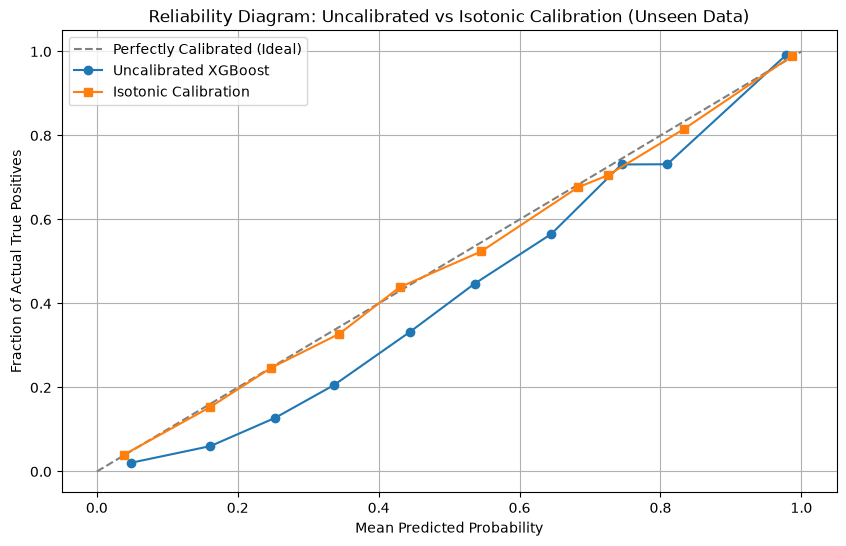

In [15]:
print("Caliberating XGBoost Probabilities")

X_calib,X_final_test,y_calib,y_final_test = train_test_split(X_test_fused,y_test,test_size=0.5,random_state=42,stratify=y_test)
caliberated_xgb = CalibratedClassifierCV(
    estimator=FrozenEstimator(xgb_fused),
    method='isotonic'
)
caliberated_xgb.fit(X_calib,y_calib)

y_probs_uncaliberated = xgb_fused.predict_proba(X_final_test)[:,2]
y_probs_caliberated = caliberated_xgb.predict_proba(X_final_test)[:,2]

y_final_test_binary = (y_final_test == 2).astype(int)

prob_true_uncal, prob_pred_uncal = calibration_curve(y_final_test_binary,y_probs_uncaliberated,n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_final_test_binary,y_probs_caliberated,n_bins=10)

plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated (Ideal)')
plt.plot(prob_pred_uncal, prob_true_uncal, marker='o', label='Uncalibrated XGBoost')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='Isotonic Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Actual True Positives')
plt.title('Reliability Diagram: Uncalibrated vs Isotonic Calibration (Unseen Data)')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
print("Freezing caliberated decision engine")

joblib.dump(caliberated_xgb,'../models/calibrated_xgb_model.joblib')

print("Saved: calibrated_xgb_model.joblib")
print("Serialization Complete")

Freezing caliberated decision engine
Saved: calibrated_xgb_model.joblib
Serialization Complete


In [17]:
print("1. Reconstructing feature names...")

numeric_features = X_train_base.columns.to_list()
alert_features = [f"alert_{word}" for word in tfidf_alert.get_feature_names_out()]
file_features = [f"alert_{word}" for word in tfidf_file.get_feature_names_out()]
all_feature_names = numeric_features + alert_features + file_features

print("2. Initializing SHAP TreeExplainer...")

explainer = shap.TreeExplainer(xgb_fused)
X_sample = X_final_test[:100].toarray()

print("3. Calculating SHAP values for the sample...")

shap_values = explainer.shap_values(X_sample)
class_2_shap = shap_values[:,:,2]



print("\n--- Generating Explanation for Incident 0 ---")

incident_0_impacts = class_2_shap[45]

## Debug step
# print(len(all_feature_names))
# print(len(incident_0_impacts))
# print(len(X_sample[0]))
# print(shap_values.shape)
# print(class_2_shap.shape)

feature_impact = pd.DataFrame({
    'Feature' : all_feature_names,
    'SHAP_values' : incident_0_impacts,  
    'Actual_value_in_data' : X_sample[45]
})

top_positive_features = feature_impact.sort_values(
    by='SHAP_values',ascending=False
).head(10
       )

print("What drives the models prediction including absence and presence of feature ?")
print(top_positive_features)

valid_drivers = feature_impact[
    (feature_impact['SHAP_values'] > 0) & (feature_impact['Actual_value_in_data'] > 0)
]

print("-"*50)

top_5_features = valid_drivers.sort_values(by='SHAP_values',ascending=False).head(10)
print("\nWhat are the positive features presents which is classifying this evidence as threat")
print(top_5_features)


1. Reconstructing feature names...
2. Initializing SHAP TreeExplainer...
3. Calculating SHAP values for the sample...

--- Generating Explanation for Incident 0 ---
What drives the models prediction including absence and presence of feature ?
                   Feature  SHAP_values  Actual_value_in_data
120               alert_39     3.286448              0.000000
117               alert_34     2.242454              0.000000
59               alert_101     1.635882              0.000000
56                 alert_1     0.226151              0.000000
68                alert_12     0.137717              0.000000
134                alert_6     0.089582              0.000000
181               alert_15     0.078600              0.000000
52          ips_per_device     0.063497              1.666667
119               alert_37     0.049289              0.000000
23   unique_filename_count     0.041548             22.000000
--------------------------------------------------

What are the positive f

In [18]:
sp.save_npz("../data/05_fused/X_calib.npz", X_calib)
sp.save_npz("../data/05_fused/X_final_test.npz", X_final_test)
sp.save_npz("../data/05_fused/X_train_fused.npz", X_train_fused)


np.save("../data/05_fused/y_calib.npy", y_calib)
np.save("../data/05_fused/y_final_test.npy", y_final_test)
np.save("../data/05_fused/y_train.npy", y_train)

print("Data frozen successfully.")

Data frozen successfully.
